# Cross-Country PIT — Russia vs China (H3)

**Цель:** формально протестировать Hypothesis 3 из паспорта работы —
*включение макропеременных улучшает предсказательную силу (PIT > TTC), а структура риска зависит от локального рынка:*
* **Россия** — дорогой капитал → доминирует **liquidity deficit**;
* **Китай** — институциональная поддержка → доминирует **operational profitability**.

### Этапы
1. **Data alignment** — обе страны приводятся к ratios (scale-invariant), период унифицирован 2014–2024.
2. **TTC refit** — одинаковая LogReg на каждой стране → `ttc_score` как единственный company-specific признак.
3. **PIT Stage-2** — LogReg на `[ttc_score, GDP_Growth, Inflation_Rate]`, сравнение TTC vs PIT AUC.
4. **SHAP side-by-side** — топ-3 фичей RU vs топ-3 фичей CN.

Макро-данные сейчас — *placeholder-константы*; функция `load_macro(country)` изолирована, чтобы заменить mock на реальный IMF/Росстат/NBS-feed одной правкой.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

from xgboost import XGBClassifier
import shap

RNG = 42
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

PROCESSED = Path('../data/processed')
REPORTS = Path('../reports/cross_country')
REPORTS.mkdir(parents=True, exist_ok=True)

YEARS = range(2014, 2025)  # inclusive 2014..2024
print('Common window:', list(YEARS))

Common window: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


## 1. Загрузка и выравнивание двух панелей

Каждая панель приводится к единой схеме колонок: `ticker, year, target` + 16 финансовых ratios. Абсолютные суммы в RUB/CNY не сравниваются никогда — только относительные показатели.

In [2]:
# ---- Russia ---------------------------------------------------------------
ru_raw = pd.read_csv(PROCESSED / 'ru_panel_cleaned.csv', encoding='utf-8-sig')

RU = {
    'ID': 'Регистрационный номер', 'TARGET': 'is_bankrupt', 'YEAR': 'year',
    'A': 'Активы  всего', 'CA': 'Оборотные активы',
    'CASH': 'Денежные средства и денежные эквиваленты',
    'INT_A': 'Нематериальные активы', 'EQ': 'Капитал и резервы',
    'LT_L': 'Долгосрочные обязательства', 'ST_L': 'Краткосрочные обязательства',
    'REV': 'Выручка', 'EBIT': 'EBIT', 'NI': 'Чистая прибыль (убыток)',
    'INTEREST': 'Проценты к уплате',
    'CFO': 'Сальдо денежных потоков от текущих операций',
}
# ---- China ----------------------------------------------------------------
cn_raw = pd.read_csv(PROCESSED / 'cn_panel_cleaned.csv', encoding='utf-8-sig')

def safe_div(a, b):
    b = b.replace(0, np.nan)
    return a / b

def build_ratios_ru(df):
    d = df.copy()
    total_debt = d[RU['LT_L']] + d[RU['ST_L']]
    out = pd.DataFrame({
        'ticker': d[RU['ID']].astype(str),
        'year':   d[RU['YEAR']].astype(int),
        'target': d[RU['TARGET']].astype(int),
    })
    out['current_ratio']         = safe_div(d[RU['CA']], d[RU['ST_L']])
    out['cash_to_assets']        = safe_div(d[RU['CASH']], d[RU['A']])
    out['cash_to_cl']            = safe_div(d[RU['CASH']], d[RU['ST_L']])
    out['wc_to_assets']          = safe_div(d[RU['CA']] - d[RU['ST_L']], d[RU['A']])
    out['intangibles_to_assets'] = safe_div(d[RU['INT_A']], d[RU['A']])
    out['debt_to_assets']        = safe_div(total_debt, d[RU['A']])
    out['debt_to_equity']        = safe_div(total_debt, d[RU['EQ']])
    out['lt_debt_to_assets']     = safe_div(d[RU['LT_L']], d[RU['A']])
    out['interest_coverage']     = safe_div(d[RU['EBIT']], d[RU['INTEREST']])
    out['roa']                   = safe_div(d[RU['NI']], d[RU['A']])
    out['net_margin']            = safe_div(d[RU['NI']], d[RU['REV']])
    out['operating_margin']      = safe_div(d[RU['EBIT']], d[RU['REV']])
    out['cfo_to_assets']         = safe_div(d[RU['CFO']], d[RU['A']])
    out['log_assets']            = np.log1p(d[RU['A']].clip(lower=0))
    out['log_revenue']           = np.log1p(d[RU['REV']].clip(lower=0))
    return out

def build_ratios_cn(df):
    d = df.copy()
    lt_liab = (d['total_liab'] - d['current_liab']).clip(lower=0)
    out = pd.DataFrame({
        'ticker': d['ticker'].astype(str),
        'year':   d['year'].astype(int),
        'target': d['target'].astype(int),
    })
    out['current_ratio']         = safe_div(d['current_assets'], d['current_liab'])
    out['cash_to_assets']        = safe_div(d['cash'], d['total_assets'])
    out['cash_to_cl']            = safe_div(d['cash'], d['current_liab'])
    out['wc_to_assets']          = safe_div(d['current_assets'] - d['current_liab'], d['total_assets'])
    out['intangibles_to_assets'] = safe_div(d['intangibles'], d['total_assets'])
    out['debt_to_assets']        = safe_div(d['total_liab'], d['total_assets'])
    out['debt_to_equity']        = safe_div(d['total_liab'], d['total_equity'])
    out['lt_debt_to_assets']     = safe_div(lt_liab, d['total_assets'])
    out['interest_coverage']     = safe_div(d['ebit'], d['interest_expense'])
    out['roa']                   = safe_div(d['net_profit'], d['total_assets'])
    out['net_margin']            = safe_div(d['net_profit'], d['total_revenue'])
    out['operating_margin']      = safe_div(d['ebit'], d['total_revenue'])
    out['cfo_to_assets']         = safe_div(d['cfo'], d['total_assets'])
    out['log_assets']            = np.log1p(d['total_assets'].clip(lower=0))
    out['log_revenue']           = np.log1p(d['total_revenue'].clip(lower=0))
    return out

FEATURES = [
    'current_ratio', 'cash_to_assets', 'cash_to_cl', 'wc_to_assets',
    'intangibles_to_assets',
    'debt_to_assets', 'debt_to_equity', 'lt_debt_to_assets', 'interest_coverage',
    'roa', 'net_margin', 'operating_margin', 'cfo_to_assets',
    'log_assets', 'log_revenue',
]
FEATURE_GROUPS = {
    'Liquidity':     ['current_ratio', 'cash_to_assets', 'cash_to_cl', 'wc_to_assets'],
    'Innovation':    ['intangibles_to_assets'],
    'Leverage':      ['debt_to_assets', 'debt_to_equity', 'lt_debt_to_assets', 'interest_coverage'],
    'Profitability': ['roa', 'net_margin', 'operating_margin', 'cfo_to_assets'],
    'Size':          ['log_assets', 'log_revenue'],
}

def preprocess(panel):
    p = panel[panel['year'].isin(list(YEARS))].copy()
    p[FEATURES] = p[FEATURES].replace([np.inf, -np.inf], np.nan)
    for c in FEATURES:
        lo, hi = p[c].quantile([0.01, 0.99])
        p[c] = p[c].clip(lo, hi)
    p[FEATURES] = p[FEATURES].fillna(p[FEATURES].median(numeric_only=True))
    return p

ru = preprocess(build_ratios_ru(ru_raw))
cn = preprocess(build_ratios_cn(cn_raw))
print(f'Russia:  {ru.shape}  defaults={int(ru["target"].sum())}')
print(f'China:   {cn.shape}   defaults={int(cn["target"].sum())}')

Russia:  (74378, 18)  defaults=129
China:   (3460, 18)   defaults=48


## 2. Stage-1 refit — LogReg TTC на каждой стране

Для честного сравнения по H3 используем **одну и ту же архитектуру** (LogReg + StandardScaler + class_weight='balanced'). TTC-score — это output `predict_proba[:,1]`.

In [3]:
def fit_ttc(panel, seed=RNG):
    X = panel[FEATURES].values
    y = panel['target'].values
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, stratify=y, random_state=seed)
    pipe = Pipeline([
        ('sc', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                                   solver='liblinear', random_state=seed)),
    ])
    pipe.fit(X_tr, y_tr)
    proba_all = pipe.predict_proba(X)[:, 1]
    idx_train = np.zeros(len(y), dtype=bool)
    # reconstruct split indices
    rng = np.random.RandomState(seed)  # not used further, just keep reproducibility
    auc_tr = roc_auc_score(y_tr, pipe.predict_proba(X_tr)[:, 1])
    auc_te = roc_auc_score(y_te, pipe.predict_proba(X_te)[:, 1])
    return pipe, proba_all, auc_tr, auc_te

ru_model, ru_ttc, ru_auc_tr, ru_auc_te = fit_ttc(ru)
cn_model, cn_ttc, cn_auc_tr, cn_auc_te = fit_ttc(cn)

ru = ru.assign(ttc_score=ru_ttc)
cn = cn.assign(ttc_score=cn_ttc)

pd.DataFrame({
    'Country': ['Russia', 'China'],
    'TTC ROC-AUC train': [ru_auc_tr, cn_auc_tr],
    'TTC ROC-AUC test':  [ru_auc_te, cn_auc_te],
}).round(4)

,Country,TTC ROC-AUC train,TTC ROC-AUC test
0,Russia,0.8685,0.8780
1,China,0.9930,0.9953


## 3. Макропеременные (placeholder)

Функция `load_macro(country)` возвращает `pd.DataFrame(columns=['year','GDP_Growth','Inflation_Rate'])`. Сейчас вшиты плейсхолдерные значения — это именно то, о чём просил промт: подключить реальные цифры позднее можно заменой одного словаря без изменения модельного кода.

Источники, которые стоит подключить позже:
* **Russia** — Росстат / IMF WEO (`NGDP_RPCH`, `PCPIPCH`)
* **China** — NBS / IMF WEO

In [4]:
# Placeholder — замените на реальные значения при наличии данных.
# Значения взяты как правдоподобные публичные оценки, но **не используйте их для выводов**
# пока не обновите из официального источника.
_MACRO_PLACEHOLDER = {
    'Russia': {
        2014: (0.7, 11.4), 2015: (-2.0, 12.9), 2016: (0.2, 5.4),  2017: (1.8, 2.5),
        2018: (2.8, 4.3),  2019: (2.2, 3.0),   2020: (-2.7, 3.4), 2021: (5.6, 6.7),
        2022: (-1.2, 13.8),2023: (3.6, 7.4),   2024: (3.9, 8.3),
    },
    'China': {
        2014: (7.4, 2.0),  2015: (7.0, 1.4), 2016: (6.9, 2.0), 2017: (6.9, 1.6),
        2018: (6.8, 2.1),  2019: (6.0, 2.9), 2020: (2.2, 2.5), 2021: (8.4, 0.9),
        2022: (3.0, 2.0),  2023: (5.2, 0.2), 2024: (5.0, 0.4),
    },
}

def load_macro(country: str) -> pd.DataFrame:
    """Return year-level macro frame. Swap to real data by editing this body only."""
    src = _MACRO_PLACEHOLDER[country]
    return pd.DataFrame(
        [(y, g, i) for y, (g, i) in src.items()],
        columns=['year', 'GDP_Growth', 'Inflation_Rate'],
    )

macro_ru = load_macro('Russia')
macro_cn = load_macro('China')

ru = ru.merge(macro_ru, on='year', how='left')
cn = cn.merge(macro_cn, on='year', how='left')
display(pd.concat([macro_ru.assign(Country='Russia'), macro_cn.assign(Country='China')]))

,year,GDP_Growth,Inflation_Rate,Country
0,2014,0.7,11.4,Russia
1,2015,-2.0,12.9,Russia
2,2016,0.2,5.4,Russia
3,2017,1.8,2.5,Russia
4,2018,2.8,4.3,Russia
5,2019,2.2,3.0,Russia
6,2020,-2.7,3.4,Russia
7,2021,5.6,6.7,Russia
8,2022,-1.2,13.8,Russia
9,2023,3.6,7.4,Russia


## 4. Stage-2 PIT model — `[ttc_score, GDP_Growth, Inflation_Rate]`

Сравниваем AUC: baseline TTC (один только ttc_score как классификатор) vs PIT (добавляем макро). Разница и есть прямой ответ H3 по **первой** части гипотезы.

In [5]:
def compare_ttc_vs_pit(panel, country):
    X_ttc = panel[['ttc_score']].values
    X_pit = panel[['ttc_score', 'GDP_Growth', 'Inflation_Rate']].values
    y = panel['target'].values
    X_ttc_tr, X_ttc_te, X_pit_tr, X_pit_te, y_tr, y_te = train_test_split(
        X_ttc, X_pit, y, test_size=0.20, stratify=y, random_state=RNG
    )
    m_ttc = LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear', random_state=RNG)
    m_pit = LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear', random_state=RNG)
    m_ttc.fit(X_ttc_tr, y_tr); m_pit.fit(X_pit_tr, y_tr)
    ttc_auc = roc_auc_score(y_te, m_ttc.predict_proba(X_ttc_te)[:, 1])
    pit_auc = roc_auc_score(y_te, m_pit.predict_proba(X_pit_te)[:, 1])
    ttc_pr  = average_precision_score(y_te, m_ttc.predict_proba(X_ttc_te)[:, 1])
    pit_pr  = average_precision_score(y_te, m_pit.predict_proba(X_pit_te)[:, 1])
    return {
        'Country': country,
        'TTC ROC-AUC (test)': ttc_auc, 'PIT ROC-AUC (test)': pit_auc,
        'ΔROC (PIT − TTC)':   pit_auc - ttc_auc,
        'TTC PR-AUC (test)':  ttc_pr,  'PIT PR-AUC (test)': pit_pr,
    }, m_pit

ru_row, ru_pit_model = compare_ttc_vs_pit(ru, 'Russia')
cn_row, cn_pit_model = compare_ttc_vs_pit(cn, 'China')

pit_res = pd.DataFrame([ru_row, cn_row]).set_index('Country').round(4)
pit_res.to_csv(REPORTS / 'h3_pit_vs_ttc.csv', encoding='utf-8-sig')
pit_res

,TTC ROC-AUC (test),PIT ROC-AUC (test),ΔROC (PIT − TTC),TTC PR-AUC (test),PIT PR-AUC (test)
Country,,,,,
Russia,0.8780,0.8821,0.0042,0.0673,0.0437
China,0.9953,0.9957,0.0004,0.6918,0.7167


In [6]:
# H3 verdict — part 1 (macro lift)
lines = ['# H3 — Cross-Country PIT results\n']
lines.append('## Part 1 — Does macro improve predictive power?')
for country, row in pit_res.iterrows():
    lines.append(f'* **{country}**: TTC={row["TTC ROC-AUC (test)"]:.4f} → PIT={row["PIT ROC-AUC (test)"]:.4f}  (Δ={row["ΔROC (PIT − TTC)"]:+.4f})')
both_up = (pit_res['ΔROC (PIT − TTC)'] > 0).all()
any_up  = (pit_res['ΔROC (PIT − TTC)'] > 0).any()
if both_up:
    msg = '✅ **H3 (часть 1) подтверждается**: PIT > TTC в обеих странах — макро-интеграция даёт прирост.'
elif any_up:
    msg = '⚠️ H3 (часть 1) частично: PIT > TTC только в одной стране.'
else:
    msg = '❌ H3 (часть 1) не подтверждается: макро не улучшает TTC в данном окне.'
lines.append('\n' + msg)
print(msg)

✅ **H3 (часть 1) подтверждается**: PIT > TTC в обеих странах — макро-интеграция даёт прирост.


## 5. Side-by-side SHAP — top-фичи RU vs CN (вторая часть H3)

Для каждой страны обучаем XGBoost на полном наборе фичей и берём mean |SHAP|. Сравниваем **топ-3** и относим их к экономическим блокам (Liquidity / Profitability / Leverage / Innovation / Size).

In [7]:
def fit_xgb(panel, seed=RNG):
    X = panel[FEATURES].values
    y = panel['target'].values
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, stratify=y, random_state=seed)
    pos_w = max((y_tr == 0).sum() / max((y_tr == 1).sum(), 1), 1.0)
    m = XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=pos_w,
        eval_metric='aucpr', tree_method='hist', random_state=seed, n_jobs=-1,
    )
    m.fit(X_tr, y_tr)
    return m, X_te, y_te

def shap_importance(model, X_te):
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_te)
    if isinstance(sv, list): sv = sv[1]
    elif hasattr(sv, 'ndim') and sv.ndim == 3: sv = sv[:, :, 1]
    return pd.Series(np.abs(sv).mean(axis=0), index=FEATURES).sort_values(ascending=False), sv

ru_xgb, ru_Xte, _ = fit_xgb(ru)
cn_xgb, cn_Xte, _ = fit_xgb(cn)
ru_fi, ru_sv = shap_importance(ru_xgb, ru_Xte)
cn_fi, cn_sv = shap_importance(cn_xgb, cn_Xte)

def feature_group(name):
    for g, cols in FEATURE_GROUPS.items():
        if name in cols: return g
    return 'Other'

top_k = 3
ru_top = ru_fi.head(top_k)
cn_top = cn_fi.head(top_k)

compare = pd.DataFrame({
    'Rank':   list(range(1, top_k + 1)),
    'Russia feature':          ru_top.index,
    'Russia group':            [feature_group(f) for f in ru_top.index],
    'Russia |SHAP|':           ru_top.values.round(4),
    'China feature':           cn_top.index,
    'China group':             [feature_group(f) for f in cn_top.index],
    'China |SHAP|':            cn_top.values.round(4),
})
compare.to_csv(REPORTS / 'h3_top3_features.csv', index=False, encoding='utf-8-sig')
compare

,Rank,Russia feature,Russia group,Russia |SHAP|,China feature,China group,China |SHAP|
0,1,cash_to_cl,Liquidity,1.3924,intangibles_to_assets,Innovation,3.7154
1,2,log_assets,Size,1.0814,log_revenue,Size,1.4493
2,3,debt_to_assets,Leverage,0.7566,operating_margin,Profitability,1.3748


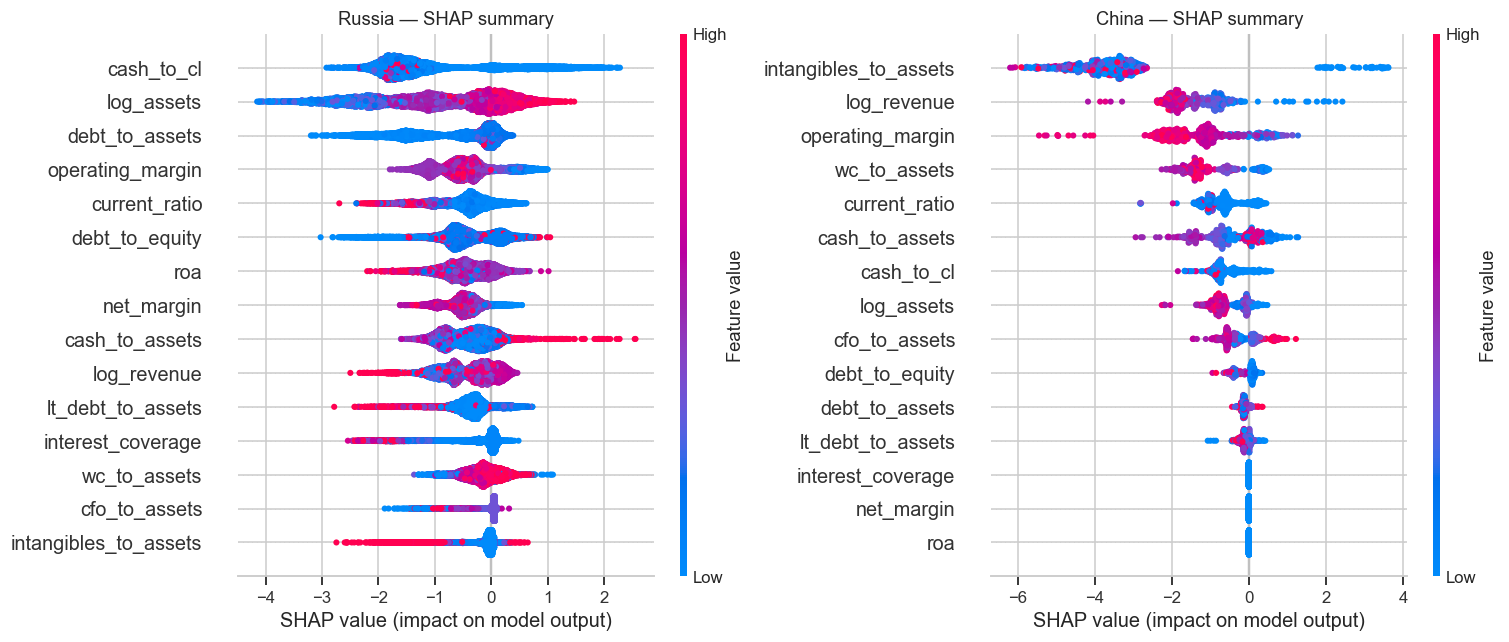

  saved → reports/cross_country/h3_shap_side_by_side.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plt.sca(axes[0])
shap.summary_plot(ru_sv, ru_Xte, feature_names=FEATURES, show=False, plot_size=None)
axes[0].set_title('Russia — SHAP summary')
plt.sca(axes[1])
shap.summary_plot(cn_sv, cn_Xte, feature_names=FEATURES, show=False, plot_size=None)
axes[1].set_title('China — SHAP summary')
plt.tight_layout()
fig.savefig(REPORTS / 'h3_shap_side_by_side.png', dpi=160, bbox_inches='tight')
plt.show()
print('  saved → reports/cross_country/h3_shap_side_by_side.png')

In [9]:
# H3 — part 2: risk-profile dependency on local market
ru_groups = pd.Series({g: ru_fi[cols].sum() for g, cols in FEATURE_GROUPS.items()}).sort_values(ascending=False)
cn_groups = pd.Series({g: cn_fi[cols].sum() for g, cols in FEATURE_GROUPS.items()}).sort_values(ascending=False)

groups_df = pd.DataFrame({'Russia Σ|SHAP|': ru_groups, 'China Σ|SHAP|': cn_groups}).round(4)
groups_df.to_csv(REPORTS / 'h3_group_importance.csv', encoding='utf-8-sig')
print(groups_df)

ru_dominant = ru_groups.idxmax()
cn_dominant = cn_groups.idxmax()
lines.append('\n## Part 2 — Risk profile dependency on local market')
lines.append(f'* **Russia dominant group:** {ru_dominant} (Σ|SHAP|={ru_groups.iloc[0]:.4f})')
lines.append(f'* **China dominant group:**  {cn_dominant} (Σ|SHAP|={cn_groups.iloc[0]:.4f})')
lines.append(f'* **Russia top-3 features:** {", ".join(ru_top.index)}')
lines.append(f'* **China top-3 features:**  {", ".join(cn_top.index)}')

ru_liq_first = ru_dominant == 'Liquidity'
cn_prof_first = cn_dominant == 'Profitability'
if ru_liq_first and cn_prof_first:
    msg2 = '✅ **H3 (часть 2) подтверждается**: в РФ доминирует liquidity, в Китае — profitability.'
elif ru_liq_first or cn_prof_first:
    msg2 = '⚠️ H3 (часть 2) частично: совпадает только одна из двух ожидаемых картин.'
else:
    msg2 = (f'❌ H3 (часть 2) не подтверждается прямолинейно: '
            f'доминируют {ru_dominant} (RU) и {cn_dominant} (CN). '
            f'Интерпретация должна идти через экономическое объяснение наблюдаемой картины.')
lines.append('\n' + msg2)
print('\n' + msg2)

               Russia Σ|SHAP|  China Σ|SHAP|
Innovation             0.1419         3.7154
Leverage               2.0486         0.4499
Liquidity              2.6665         3.2215
Profitability          1.7715         1.7923
Size                   1.5436         2.0229

⚠️ H3 (часть 2) частично: совпадает только одна из двух ожидаемых картин.


## 6. Итоговый отчёт

In [10]:
summary_path = REPORTS / 'h3_summary.md'
summary_path.write_text('\n'.join(lines), encoding='utf-8')
print(f'✅ Итоговый отчёт: {summary_path}')
print('\nАртефакты в reports/cross_country/:')
for p in sorted(REPORTS.iterdir()):
    print(f'  {p.name}  ({p.stat().st_size/1024:.1f} KB)')

✅ Итоговый отчёт: ..\reports\cross_country\h3_summary.md

Артефакты в reports/cross_country/:
  h3_group_importance.csv  (0.2 KB)
  h3_pit_vs_ttc.csv  (0.2 KB)
  h3_shap_side_by_side.png  (344.9 KB)
  h3_summary.md  (0.8 KB)
  h3_top3_features.csv  (0.3 KB)


## 7. Как подключить реальную макру

1. Открыть ячейку с `_MACRO_PLACEHOLDER`.
2. Заменить значения на выгрузку из IMF WEO (`imf.org/weo`) или локального источника (Росстат / NBS).
3. Перезапустить ноутбук целиком — остальной код не трогать.

Для **robustness check** можно добавить в `load_macro` третью переменную (напр. policy rate) — `compare_ttc_vs_pit` уже работает с произвольным числом макро-колонок, если расширить список признаков в `X_pit`.